# Feature Extraction using Pretrained Models

This notebook provides a framework for extracting features from medical images using pretrained models. The features can be extracted using **task-agnostic models** (general-purpose deep learning models) or **task-specific models** (designed for specific medical tasks, such as chest X-ray classification).

## Feature Extraction Methods

### Task-Agnostic Models

- These models are general-purpose convolutional neural networks (CNNs) pretrained on large datasets such as ImageNet.
- Models like ResNet, VGG16, DenseNet, and Inception project high-dimensional image data into a reduced, meaningful feature space.
- Suitable for exploring general patterns in data without focusing on a specific task.

#### Supported Models:
- ResNet, VGG16, DenseNet, EfficientNet, MobileNet, Inception, ResNeXt, Wide ResNet, Vision Transformer (ViT).

#### Example Workflow:
1. Choose a model (e.g., ResNet).
2. Provide the path to the in-distribution (and optionally out-distribution) image folders.
3. Extract and save features to CSV files for further analysis.

#### Advantages:
- Quick setup without requiring a task-specific dataset.
- Useful for studying general data patterns.

---

### Task-Specific Models

- These models are pretrained for specific medical tasks (e.g., pneumonia detection in chest X-rays).
- Leverage learned representations tailored to specific objectives.
- Models like the NIH CXR DenseNet (available in the TorchXRayVision library) are optimized for medical applications.

#### Options:
1. **Use a user-provided task-specific model**: Provide a trained model saved locally.
2. **Use the TorchXRayVision DenseNet**: A publicly available model pretrained on the NIH Chest X-ray dataset.

#### Example Workflow:
1. Select a task-specific model (either provided by the user or from TorchXRayVision).
2. Provide the path to the image folder(s).
3. Extract and save features to CSV files for further analysis.

#### Advantages:
- Better alignment with specific medical imaging tasks.

---

## Steps in the Notebook

### 1. Select the Method:
- Choose between task-agnostic or task-specific models.
- For task-specific models, decide whether to use a user-provided model or a TorchXRayVision model.

### 2. Provide Image Data:
- Specify the path to the **in-distribution folder** (mandatory).
- Optionally specify the path to the **out-distribution folder**.

### 3. Extract Features:
- The selected model processes the images to extract meaningful features.
- The features are saved as CSV files for further use.

### 4. Visualize and Analyze Features:
- Visualize feature distributions using **t-SNE**, **PCA**, **UMAP**, or other methods.
- Compare distributions between in-distribution and out-distribution datasets.

---

## Outputs

### Feature CSV Files:
- **In-distribution features** are saved to a specified CSV file.
- **Out-distribution features** (if provided) are saved to a separate CSV file.

### Visualizations:
- Dimensionality reduction techniques (e.g., PCA, t-SNE) and distribution plots help analyze the extracted features.




***Running this code requires the following packages***
* torch>=1.12.0
* torchvision>=0.13.0
* torchxrayvision>=0.0.32
* SimpleITK>=2.2.0
* pyradiomics>=3.0.1
* seaborn>=0.11.2
* umap-learn>=0.5.3
* scikit-image>=0.20.0
* gudhi>=3.5.0
* Pillow>=9.0.0
* numpy>=1.21.0
* pandas>=1.3.0
* matplotlib>=3.4.3



In [ ]:
# Core Libraries
import os  # For directory and file handling
import numpy as np  # For numerical operations
import pandas as pd  # For data manipulation

# PyTorch and Related Libraries
import torch  # For deep learning operations
import torchvision.models as models  # For pre-trained models
from torchvision import transforms  # For image preprocessing
from PIL import Image  # For handling image files

# Image Processing Libraries
import skimage.io  # For reading images
import torchxrayvision as xrv  # For medical imaging models and utilities

# Visualization Libraries
import matplotlib.pyplot as plt  # For creating plots
import seaborn as sns  # For advanced visualization

# Machine Learning Libraries
from sklearn.preprocessing import StandardScaler  # For feature scaling
from sklearn.decomposition import PCA  # For dimensionality reduction
from sklearn.manifold import TSNE  # For t-SNE visualization
from umap import UMAP  # For UMAP dimensionality reduction
from sklearn.impute import SimpleImputer  # For handling missing values


In [ ]:
def extract_features_task_agnostic(model_name, img_path):
    """
    Extract features using a pretrained task-agnostic model.

    Parameters:
        model_name (str): Name of the model (e.g., ResNet, ViT, Inception).
        img_path (str): Path to the input image.

    Returns:
        Tensor: Extracted features.
    """
    # Load the image
    image = Image.open(img_path).convert("RGB")

    # Define preprocessing based on the model
    if model_name == "Inception":
        preprocess = transforms.Compose([
            transforms.Resize((299, 299)),  # Inception requires 299x299 input size
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        preprocess = transforms.Compose([
            transforms.Resize((224, 224)),  # Default size for most models
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    img_tensor = preprocess(image).unsqueeze(0)  # Add batch dimension

    # Load the model
    if model_name == "ViT":
        model = models.vit_b_16(pretrained=True)
        model.eval()

        # Forward pass through the model
        with torch.no_grad():
            outputs = model(img_tensor)

        # Handle ViT output
        # Pool embeddings: Global Average Pooling
        pooled_features = torch.mean(outputs, dim=(-2, -1))  # Mean across spatial dimensions
        return pooled_features

    elif model_name == "Inception":
        model = models.inception_v3(pretrained=True, aux_logits=True)  # Use aux_logits=True
        model.eval()

        # Forward pass through the model
        with torch.no_grad():
            outputs = model(img_tensor)

        # Extract the primary output (ignore auxiliary logits)
        features = outputs[0] if isinstance(outputs, tuple) else outputs

        # Flatten the output
        return features.flatten(start_dim=1)

    else:
        # For other models (e.g., ResNet, VGG, etc.)
        if model_name == "ResNet":
            model = models.resnet50(pretrained=True)
        elif model_name == "VGG16":
            model = models.vgg16(pretrained=True)
        elif model_name == "DenseNet":
            model = models.densenet121(pretrained=True)
        elif model_name == "EfficientNet":
            model = models.efficientnet_b0(pretrained=True)
        elif model_name == "MobileNet":
            model = models.mobilenet_v2(pretrained=True)
        elif model_name == "ResNeXt":
            model = models.resnext50_32x4d(pretrained=True)
        elif model_name == "Wide_ResNet":
            model = models.wide_resnet50_2(pretrained=True)
        else:
            raise ValueError(f"Model {model_name} not supported.")

        model.eval()
        model = torch.nn.Sequential(*list(model.children())[:-1])  # Remove the classifier head

        # Forward pass
        with torch.no_grad():
            features = model(img_tensor)

        # Flatten the output
        return features.flatten(start_dim=1)


In [ ]:
def extract_features_task_specific(use_provided_model, img_path, model=None):
    """
    Extract features using a task-specific model.

    Parameters:
        use_provided_model (bool): Whether to use a user-provided model.
        img_path (str): Path to the input image.
        model: Pre-initialized model to use for feature extraction.

    Returns:
        Tensor: Extracted features.
    """
    # Transform the input image
    transform = transforms.Compose([
        xrv.datasets.XRayCenterCrop(),
        xrv.datasets.XRayResizer(224)
    ])

    img = skimage.io.imread(img_path)
    img = xrv.datasets.normalize(img, 255)  # Normalize pixel values
    if len(img.shape) == 2:  # Handle grayscale images
        img = img[None, ...]  # Add channel dimension
    elif img.shape[-1] == 3:  # Convert RGB to single channel
        img = img.mean(2)[None, ...]
    else:
        raise ValueError(f"Unexpected image shape: {img.shape}")

    img = transform(img)  # Resize and crop
    img = torch.from_numpy(img).unsqueeze(0).float()  # Add batch dimension and convert to tensor

    # Extract features
    with torch.no_grad():
        features = model.features(img)
    return features

In [ ]:
def validate_output_path(output_path, default_filename):
    if os.path.isdir(output_path):
        return os.path.join(output_path, default_filename)
    return output_path

In [ ]:

def save_features_to_csv(features, output_file, image_name):
    """
    Save extracted features to a CSV file.

    Parameters:
        features (Tensor or ndarray): Extracted features from the model.
        output_file (str): Path to the output CSV file where features will be saved.
        image_name (str): Name of the image file being processed.

    Workflow:
    - Converts the features tensor to a NumPy array if required.
    - Ensures the features are saved in a flattened 1D format.
    - If the output file does not exist, it creates the file and writes a header row.
    - Appends the image name and extracted features as a new row.
    """
    if isinstance(features, torch.Tensor):
        features = features.squeeze().cpu().numpy()
    if isinstance(features, np.ndarray):
        features = features.tolist()
    if not isinstance(features, list):
        features = [features]

    # Combine image name and features into a single row
    row = [image_name] + features

    # Write header and data to the file
    if not os.path.exists(output_file):
        with open(output_file, "w") as f:
            header = ["Image_Name"] + [f"Feature_{i}" for i in range(len(features))]
            f.write(",".join(header) + "\n")
            f.write(",".join(map(str, row)) + "\n")
    else:
        with open(output_file, "a") as f:
            f.write(",".join(map(str, row)) + "\n")

In [ ]:
if __name__ == "__main__":
    """
    Main execution block for extracting features and saving them to CSV files.

    Steps:
    1. Choose the feature extraction method (Task-Agnostic or Task-Specific).
    2. Provide paths for in-distribution and out-distribution image folders.
    3. Specify where the extracted features should be saved.
    4. For task-specific models:
        - Choose between a custom model or the TorchXRayVision NIH DenseNet model.
    5. Extract and save features for each image in the specified folders.
    """
    print("Choose a feature extraction method:")
    print("1: Task-Agnostic Model (ResNet, VGG16, DenseNet, etc.)")
    print("2: Task-Specific Model (e.g., TorchXRayVision or user-provided model)")

    method = input("Enter the method (1 or 2): ").strip()

    # Input folder paths
    in_dist_folder = input("Enter the path to the in-distribution (Reference data) folder: ").strip()
    if not os.path.exists(in_dist_folder):
        print("Invalid in-distribution folder path. Ending program.")
        exit()

    out_dist_folder = input("Enter the path to the out-distribution (Test data) folder (or 'NA' if not available): ").strip()
    if out_dist_folder.upper() != "NA" and not os.path.exists(out_dist_folder):
        print("Invalid out-distribution folder path. Ending program.")
        exit()

    # Output folder paths
    in_dist_output = input("Enter the folder where the in-distribution features will be saved: ").strip()
    out_dist_output = input("Enter the folder where the out-distribution features will be saved (or 'NA' if not available): ").strip()

    # Validate output paths
    in_dist_output = validate_output_path(in_dist_output, "in_dist_features.csv")
    if out_dist_output.upper() != "NA":
        out_dist_output = validate_output_path(out_dist_output, "out_dist_features.csv")

    print(f"In-Distribution features will be saved to: {in_dist_output}")
    if out_dist_output.upper() != "NA":
        print(f"Out-Distribution features will be saved to: {out_dist_output}")

    if method == "1":
        # Task-Agnostic Model Processing
        print("Available models: ResNet, VGG16, DenseNet, EfficientNet, MobileNet, Inception, ResNeXt, Wide_ResNet, ViT")
        model_name = input("Enter the model name: ").strip()

        # Extract features from in-distribution images
        print(f"Extracting features from in-distribution folder: {in_dist_folder}")
        for img_file in os.listdir(in_dist_folder):
            img_path = os.path.join(in_dist_folder, img_file)
            if os.path.isfile(img_path):
                features = extract_features_task_agnostic(model_name, img_path)
                save_features_to_csv(features, in_dist_output, img_file)
                print(f"Features extracted and saved for {img_file}")

        # Extract features from out-distribution images, if applicable
        if out_dist_folder.upper() != "NA":
            print(f"Extracting features from out-distribution folder: {out_dist_folder}")
            for img_file in os.listdir(out_dist_folder):
                img_path = os.path.join(out_dist_folder, img_file)
                if os.path.isfile(img_path):
                    features = extract_features_task_agnostic(model_name, img_path)
                    save_features_to_csv(features, out_dist_output, img_file)
                    print(f"Features extracted and saved for {img_file}")

    elif method == "2":
        # Task-Specific Model Processing
        print("Choose task-specific model option:")
        print("1: Provide your own task-specific model path")
        print("2: Use TorchXRayVision NIH CXR model")
        option = input("Enter your choice (1 or 2): ").strip()

        model = None
        if option == "1":
            provided_model_path = input("Enter the path to your task-specific model: ").strip()
            if not os.path.exists(provided_model_path):
                print("Invalid task-specific model path. Ending program.")
                exit()
            model = torch.load(provided_model_path)
        elif option == "2":
            print("\nNote: This code uses the TorchXRayVision NIH DenseNet model for demonstration.")
            print("Explore other task-specific models available in the TorchXRayVision library here:")
            print("https://github.com/mlmed/torchxrayvision\n")
            model = xrv.models.DenseNet(weights="densenet121-res224-nih")

        # Ensure model is in evaluation mode
        model.eval()

        # Extract features from in-distribution images
        print(f"Extracting features from in-distribution folder: {in_dist_folder}")
        for img_file in os.listdir(in_dist_folder):
            img_path = os.path.join(in_dist_folder, img_file)
            if os.path.isfile(img_path):
                features = extract_features_task_specific(option == "1", img_path, model=model)
                save_features_to_csv(features, in_dist_output, img_file)
                print(f"Features extracted and saved for {img_file}")

        # Extract features from out-distribution images, if applicable
        if out_dist_folder.upper() != "NA":
            print(f"Extracting features from out-distribution folder: {out_dist_folder}")
            for img_file in os.listdir(out_dist_folder):
                img_path = os.path.join(out_dist_folder, img_file)
                if os.path.isfile(img_path):
                    features = extract_features_task_specific(option == "1", img_path, model=model)
                    save_features_to_csv(features, out_dist_output, img_file)
                    print(f"Features extracted and saved for {img_file}")

    else:
        print("Invalid method choice. Ending program.")
        exit()


In [ ]:
if __name__ == "__main__":
    """
    Main execution block for extracting features and saving them to CSV files.

    Steps:
    1. Choose the feature extraction method (Task-Agnostic or Task-Specific).
    2. Provide paths for in-distribution and out-distribution image folders.
    3. Specify where the extracted features should be saved.
    4. For task-specific models:
        - Choose between a custom model or the TorchXRayVision NIH DenseNet model.
    5. Extract and save features for each image in the specified folders.
    """
    print("Choose a feature extraction method:")
    print("1: Task-Agnostic Model (ResNet, VGG16, DenseNet, etc.)")
    print("2: Task-Specific Model (e.g., TorchXRayVision or user-provided model)")

    method = input("Enter the method (1 or 2): ").strip()

    # Input folder paths
    in_dist_folder = input("Enter the path to the in-distribution (Reference data) folder: ").strip()
    if not os.path.exists(in_dist_folder):
        print("Invalid in-distribution folder path. Ending program.")
        exit()

    out_dist_folder = input("Enter the path to the out-distribution (Test data) folder (or 'NA' if not available): ").strip()
    if out_dist_folder.upper() != "NA" and not os.path.exists(out_dist_folder):
        print("Invalid out-distribution folder path. Ending program.")
        exit()

    # Output folder paths
    in_dist_output = input("Enter the folder where the in-distribution features will be saved: ").strip()
    out_dist_output = input("Enter the folder where the out-distribution features will be saved (or 'NA' if not available): ").strip()

    # Validate output paths
    in_dist_output = validate_output_path(in_dist_output, "in_dist_features.csv")
    if out_dist_output.upper() != "NA":
        out_dist_output = validate_output_path(out_dist_output, "out_dist_features.csv")

    print(f"In-Distribution features will be saved to: {in_dist_output}")
    if out_dist_output.upper() != "NA":
        print(f"Out-Distribution features will be saved to: {out_dist_output}")

    if method == "1":
        # Task-Agnostic Model Processing
        print("Available models: ResNet, VGG16, DenseNet, EfficientNet, MobileNet, Inception, ResNeXt, Wide_ResNet, ViT")
        model_name = input("Enter the model name: ").strip()

        # Extract features from in-distribution images
        print(f"Extracting features from in-distribution folder: {in_dist_folder}")
        for img_file in os.listdir(in_dist_folder):
            img_path = os.path.join(in_dist_folder, img_file)
            if os.path.isfile(img_path):
                features = extract_features_task_agnostic(model_name, img_path)
                save_features_to_csv(features, in_dist_output, img_file)
                print(f"Features extracted and saved for {img_file}")

        # Extract features from out-distribution images, if applicable
        if out_dist_folder.upper() != "NA":
            print(f"Extracting features from out-distribution folder: {out_dist_folder}")
            for img_file in os.listdir(out_dist_folder):
                img_path = os.path.join(out_dist_folder, img_file)
                if os.path.isfile(img_path):
                    features = extract_features_task_agnostic(model_name, img_path)
                    save_features_to_csv(features, out_dist_output, img_file)
                    print(f"Features extracted and saved for {img_file}")

    elif method == "2":
        # Task-Specific Model Processing
        print("Choose task-specific model option:")
        print("1: Provide your own task-specific model path")
        print("2: Use TorchXRayVision NIH CXR model")
        option = input("Enter your choice (1 or 2): ").strip()

        model = None
        if option == "1":
            provided_model_path = input("Enter the path to your task-specific model: ").strip()
            if not os.path.exists(provided_model_path):
                print("Invalid task-specific model path. Ending program.")
                exit()
            model = torch.load(provided_model_path)
        elif option == "2":
            print("\nNote: This code uses the TorchXRayVision NIH DenseNet model for demonstration.")
            print("Explore other task-specific models available in the TorchXRayVision library here:")
            print("https://github.com/mlmed/torchxrayvision\n")
            model = xrv.models.DenseNet(weights="densenet121-res224-nih")

        # Ensure model is in evaluation mode
        model.eval()

        # Extract features from in-distribution images
        print(f"Extracting features from in-distribution folder: {in_dist_folder}")
        for img_file in os.listdir(in_dist_folder):
            img_path = os.path.join(in_dist_folder, img_file)
            if os.path.isfile(img_path):
                features = extract_features_task_specific(option == "1", img_path, model=model)
                save_features_to_csv(features, in_dist_output, img_file)
                print(f"Features extracted and saved for {img_file}")

        # Extract features from out-distribution images, if applicable
        if out_dist_folder.upper() != "NA":
            print(f"Extracting features from out-distribution folder: {out_dist_folder}")
            for img_file in os.listdir(out_dist_folder):
                img_path = os.path.join(out_dist_folder, img_file)
                if os.path.isfile(img_path):
                    features = extract_features_task_specific(option == "1", img_path, model=model)
                    save_features_to_csv(features, out_dist_output, img_file)
                    print(f"Features extracted and saved for {img_file}")

    else:
        print("Invalid method choice. Ending program.")
        exit()


Choose a feature extraction method:
1: Task-Agnostic Model (ResNet, VGG16, DenseNet, etc.)
2: Task-Specific Model (e.g., TorchXRayVision or user-provided model)
Enter the method (1 or 2): 1
Enter the path to the in-distribution (Reference data) folder: /content/drive/MyDrive/DataMonitor/in_dist_pool
Enter the path to the out-distribution (Test data) folder (or 'NA' if not available): /content/drive/MyDrive/DataMonitor/out-dist-cxr
Enter the folder where the in-distribution features will be saved: /content/drive/MyDrive/DataMonitor/
Enter the folder where the out-distribution features will be saved (or 'NA' if not available): /content/drive/MyDrive/DataMonitor/
In-Distribution features will be saved to: /content/drive/MyDrive/DataMonitor/in_dist_features.csv
Out-Distribution features will be saved to: /content/drive/MyDrive/DataMonitor/out_dist_features.csv
Available models: ResNet, VGG16, DenseNet, EfficientNet, MobileNet, Inception, ResNeXt, Wide_ResNet, ViT
Enter the model name: Ince

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 166MB/s] 


Features extracted and saved for ec81f707-4d7c-4a97-ab27-048c805f5395.png
Features extracted and saved for c04f9256-7358-42ef-b843-19dbf64ef287.png
Features extracted and saved for b87a09c7-b7fa-4869-b7aa-0b2a395a4215.png
Features extracted and saved for 8e09afee-7a2c-4a53-84ed-ed2dad8d02be.png
Features extracted and saved for af33db14-7cd0-4a94-90a3-6d912c1b2d1f.png
Features extracted and saved for dee34d09-f146-45ec-a1c1-4cb4686878b8.png
Features extracted and saved for 2ca09b04-a0a9-4592-be28-bb6a47dc1732.png
Features extracted and saved for 50d01d67-020b-4806-8ceb-b2838fb8709c.png
Features extracted and saved for 3164b8ce-f84e-47db-9c14-e78890c955ed.png
Features extracted and saved for d3cf99c7-e7d7-456e-9e34-0312876db0d4.png
Features extracted and saved for 26c15b0a-9865-414d-94b2-5349e8903f88.png
Features extracted and saved for bc01023b-a656-4ee6-87fe-90382e7af127.png
Features extracted and saved for b58e15a4-085f-4d55-91e6-7d219ff570b5.png
Features extracted and saved for c236d

In [ ]:
# --------- Feature Loading and Preprocessing --------- #

"""
This section of the code focuses on loading, cleaning, and preprocessing the extracted features
from the in-distribution (reference) and out-distribution (test) datasets. It prepares the data
for visualization and analysis.

Steps:
1. Load extracted features from CSV files.
2. Handle missing values and non-numeric columns.
3. Ensure compatibility by selecting only common features between datasets.
4. Combine datasets and assign labels for identification during visualization.
5. Impute any remaining missing values and standardize the features.
"""

# Load in-distribution and out-distribution feature CSV files
try:
    in_dist_features = pd.read_csv("/content/drive/MyDrive/DataMonitor/in_dist_features.csv", on_bad_lines="skip")
    out_dist_features = pd.read_csv("/content/drive/MyDrive/DataMonitor/out_dist_features.csv", on_bad_lines="skip")
    print("Feature files loaded successfully.")
except pd.errors.ParserError as e:
    print(f"ParserError: {e}")
    print("Ensure the CSV files are correctly formatted and do not contain unexpected errors.")
    raise
except FileNotFoundError as e:
    print(f"FileNotFoundError: {e}")
    print("Ensure the file paths are correct and the files exist in the specified locations.")
    raise

# Drop rows with missing values to maintain data integrity
in_dist_features = in_dist_features.dropna()
out_dist_features = out_dist_features.dropna()

# Extract numeric columns for feature analysis (exclude non-numeric metadata like 'Image_Name')
in_dist_values = in_dist_features.drop(columns=["Image_Name"]).select_dtypes(include=[np.number])
out_dist_values = out_dist_features.drop(columns=["Image_Name"]).select_dtypes(include=[np.number])

# Ensure both datasets have a matching set of features (shared column names)
common_columns = set(in_dist_values.columns) & set(out_dist_values.columns)
if not common_columns:
    raise ValueError("No common columns found between in-distribution and out-distribution features.")

# Retain only the common feature columns
in_dist_values = in_dist_values[list(common_columns)]
out_dist_values = out_dist_values[list(common_columns)]

# Combine datasets for preprocessing and visualization
# Assign labels: 0 for in-distribution, 1 for out-distribution
combined_values = pd.concat([in_dist_values, out_dist_values], axis=0)
labels = np.array([0] * len(in_dist_values) + [1] * len(out_dist_values))

# Impute missing values with the mean of each feature
# This ensures no gaps in the data that could affect scaling or analysis
imputer = SimpleImputer(strategy="mean")
combined_values = imputer.fit_transform(combined_values)

# Standardize features for numerical stability during visualization (e.g., PCA, t-SNE)
# StandardScaler ensures all features have zero mean and unit variance
scaler = StandardScaler()
scaled_combined_values = scaler.fit_transform(combined_values)

print("Feature preprocessing completed successfully.")


Feature files loaded successfully.
Feature preprocessing completed successfully.


Visualizing Global Feature Distributions...


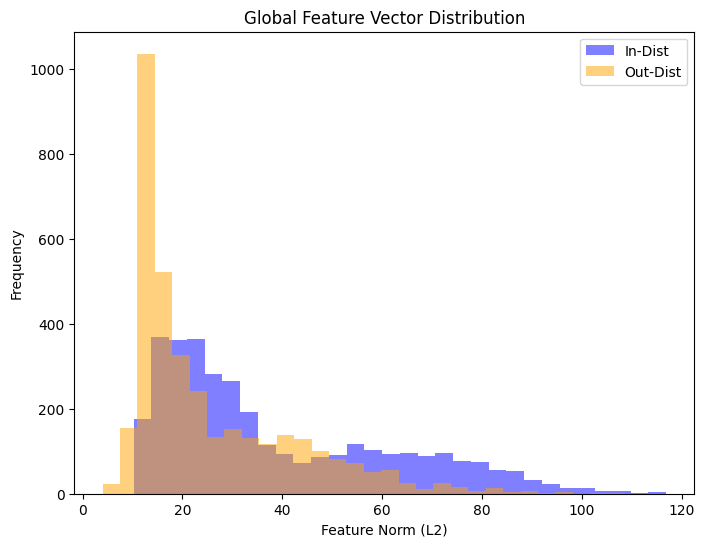

In [ ]:
# --------- Visualization Function --------- #

"""
This function visualizes the aggregated feature distributions of in-distribution
and out-distribution datasets. It provides insights into how feature norms
differ between the two datasets, helping to identify potential distribution shifts.

Steps:
1. Aggregate features into global vectors using the L2 norm.
2. Plot histograms of the aggregated feature norms for both datasets.
3. Compare the distributions to understand the separability of the two datasets.
"""

def plot_global_feature_distributions(in_features, out_features):
    """
    Plot the distribution of aggregated (global) feature vectors for in-distribution
    and out-distribution datasets.

    Parameters:
        in_features (DataFrame): Numeric features from the in-distribution dataset.
        out_features (DataFrame): Numeric features from the out-distribution dataset.
    """
    # Step 1: Aggregate features using the L2 norm (vector magnitude)
    in_global = np.linalg.norm(in_features, axis=1)  # L2 norm for in-distribution features
    out_global = np.linalg.norm(out_features, axis=1)  # L2 norm for out-distribution features

    # Step 2: Plot the histograms of the global feature distributions
    plt.figure(figsize=(8, 6))
    plt.hist(in_global, bins=30, alpha=0.5, label="In-Dist", color="blue")  # In-distribution
    plt.hist(out_global, bins=30, alpha=0.5, label="Out-Dist", color="orange")  # Out-distribution

    # Step 3: Customize the plot for clarity and interpretation
    plt.title("Global Feature Vector Distribution")  # Set the plot title
    plt.xlabel("Feature Norm (L2)")  # Label the x-axis
    plt.ylabel("Frequency")  # Label the y-axis
    plt.legend()  # Add a legend to distinguish the datasets
    plt.show()  # Display the plot

# --------- Visualization Call --------- #

"""
Call the visualization function with the processed feature datasets.
This provides an overview of the global feature distributions, allowing
a visual comparison of the in-distribution and out-distribution data.
"""

print("Visualizing Global Feature Distributions...")
plot_global_feature_distributions(in_dist_values, out_dist_values)


Visualizing Global KDE Distributions...


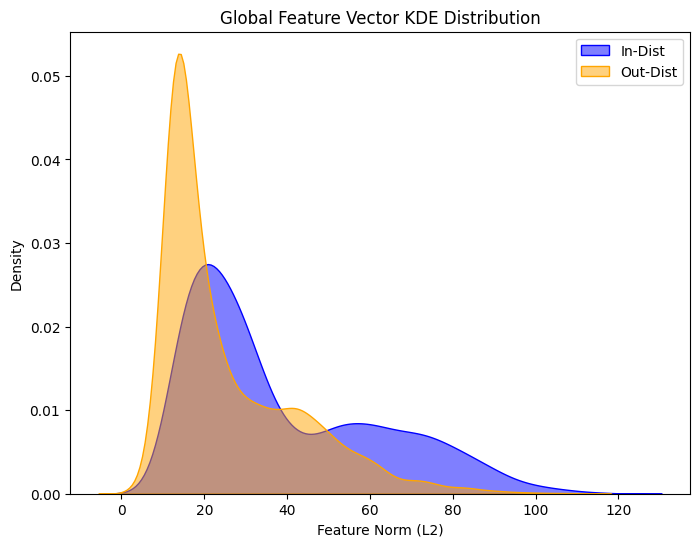

In [ ]:
# --------- Visualization Function --------- #

"""
This function visualizes the aggregated feature distributions of in-distribution
and out-distribution datasets using Kernel Density Estimation (KDE).
KDE provides a smooth estimation of the probability density function,
making it easier to interpret feature overlaps or separability between datasets.

Steps:
1. Aggregate features into global vectors using the L2 norm.
2. Use KDE to estimate the density of the aggregated feature vectors for both datasets.
3. Plot and compare the KDE curves to understand dataset separability.
"""

def plot_global_kde_distributions(in_features, out_features):
    """
    Plot KDE (Kernel Density Estimation) distributions of aggregated (global)
    feature vectors for in-distribution and out-distribution datasets.

    Parameters:
        in_features (DataFrame): Numeric features from the in-distribution dataset.
        out_features (DataFrame): Numeric features from the out-distribution dataset.
    """
    # Step 1: Aggregate features into global vectors using the L2 norm (vector magnitude)
    in_global = np.linalg.norm(in_features, axis=1)  # L2 norm for in-distribution features
    out_global = np.linalg.norm(out_features, axis=1)  # L2 norm for out-distribution features

    # Step 2: Plot the KDE distributions for both datasets
    plt.figure(figsize=(8, 6))
    sns.kdeplot(in_global, label="In-Dist", color="blue", fill=True, alpha=0.5)  # In-distribution KDE
    sns.kdeplot(out_global, label="Out-Dist", color="orange", fill=True, alpha=0.5)  # Out-distribution KDE

    # Step 3: Customize the plot for clarity and interpretation
    plt.title("Global Feature Vector KDE Distribution")  # Set the plot title
    plt.xlabel("Feature Norm (L2)")  # Label the x-axis
    plt.ylabel("Density")  # Label the y-axis
    plt.legend()  # Add a legend to distinguish the datasets
    plt.show()  # Display the plot

# --------- Visualization Call --------- #

"""
Call the visualization function with the processed feature datasets.
This provides a smooth density estimation (KDE) of the global feature distributions,
allowing for visual interpretation of dataset overlaps or separability.
"""

print("Visualizing Global KDE Distributions...")
plot_global_kde_distributions(in_dist_values, out_dist_values)


Visualizing Features using t-SNE...


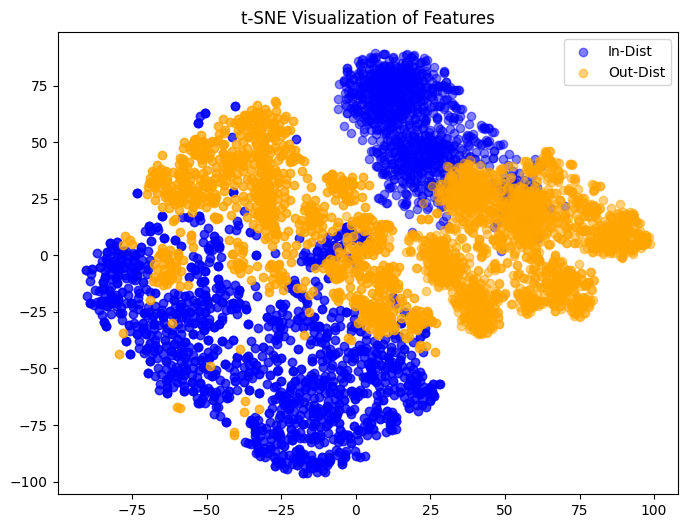

Visualizing Features using PCA...


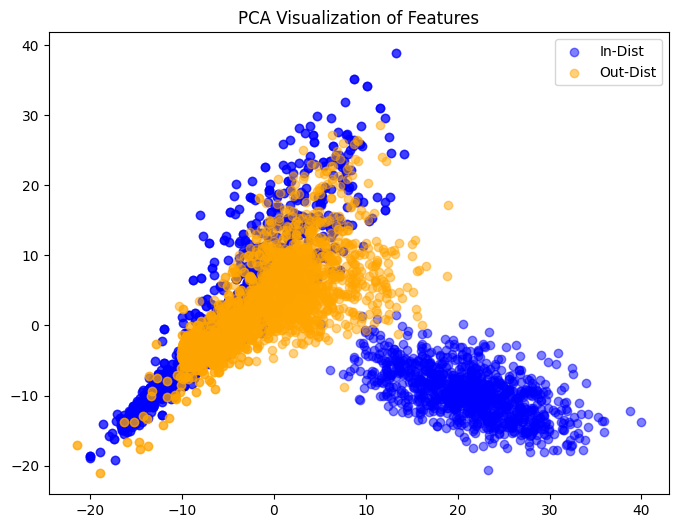

Visualizing Features using UMAP...


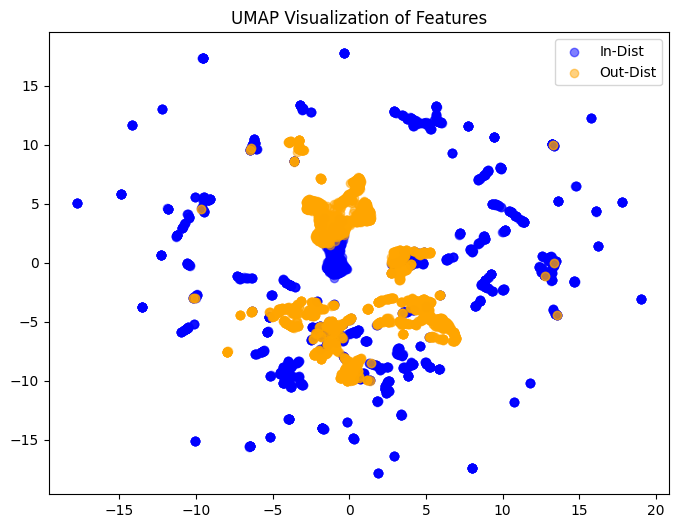

In [ ]:
# --------- Visualization Functions --------- #

def plot_tsne(features, labels):
    """
    Visualize feature data using t-SNE (t-distributed Stochastic Neighbor Embedding).

    Parameters:
        features (ndarray): Feature matrix (samples x features).
        labels (ndarray): Array of labels (0 for in-distribution, 1 for out-distribution).

    Notes:
        - t-SNE is a nonlinear dimensionality reduction technique suitable for visualizing
          high-dimensional data in 2D.
        - The `init="random"` initializes embeddings randomly to avoid convergence bias.
        - If the input has fewer than 2 samples or features, the function skips visualization.
    """
    if features.shape[1] < 2 or features.shape[0] < 2:
        print("Insufficient features or samples for t-SNE visualization. Skipping...")
        return

    tsne = TSNE(n_components=2, random_state=42, init="random")  # t-SNE with 2D output
    reduced_features = tsne.fit_transform(features)  # Reduce to 2D

    plt.figure(figsize=(8, 6))
    for label, color, label_name in zip([0, 1], ["blue", "orange"], ["In-Dist", "Out-Dist"]):
        idx = labels == label
        plt.scatter(reduced_features[idx, 0], reduced_features[idx, 1],
                    alpha=0.5, label=label_name, c=color)  # Scatter plot
    plt.title("t-SNE Visualization of Features")
    plt.legend()
    plt.show()

def plot_pca(features, labels):
    """
    Visualize feature data using PCA (Principal Component Analysis).

    Parameters:
        features (ndarray): Feature matrix (samples x features).
        labels (ndarray): Array of labels (0 for in-distribution, 1 for out-distribution).

    Notes:
        - PCA is a linear dimensionality reduction technique that projects data
          onto principal axes to maximize variance.
        - The first two principal components are used for visualization.
        - If the input has fewer than 2 samples or features, the function skips visualization.
    """
    if features.shape[1] < 2 or features.shape[0] < 2:
        print("Insufficient features or samples for PCA visualization. Skipping...")
        return

    pca = PCA(n_components=2)  # PCA with 2D output
    reduced_features = pca.fit_transform(features)  # Reduce to 2D

    plt.figure(figsize=(8, 6))
    for label, color, label_name in zip([0, 1], ["blue", "orange"], ["In-Dist", "Out-Dist"]):
        idx = labels == label
        plt.scatter(reduced_features[idx, 0], reduced_features[idx, 1],
                    alpha=0.5, label=label_name, c=color)  # Scatter plot
    plt.title("PCA Visualization of Features")
    plt.legend()
    plt.show()

def plot_umap(features, labels):
    """
    Visualize feature data using UMAP (Uniform Manifold Approximation and Projection).

    Parameters:
        features (ndarray): Feature matrix (samples x features).
        labels (ndarray): Array of labels (0 for in-distribution, 1 for out-distribution).

    Notes:
        - UMAP is a nonlinear dimensionality reduction technique that preserves
          global and local data structure for better visualization.
        - If the input has fewer than 2 samples or features, the function skips visualization.
    """
    if features.shape[1] < 2 or features.shape[0] < 2:
        print("Insufficient features or samples for UMAP visualization. Skipping...")
        return

    umap = UMAP(n_components=2, random_state=42)  # UMAP with 2D output
    reduced_features = umap.fit_transform(features)  # Reduce to 2D

    plt.figure(figsize=(8, 6))
    for label, color, label_name in zip([0, 1], ["blue", "orange"], ["In-Dist", "Out-Dist"]):
        idx = labels == label
        plt.scatter(reduced_features[idx, 0], reduced_features[idx, 1],
                    alpha=0.5, label=label_name, c=color)  # Scatter plot
    plt.title("UMAP Visualization of Features")
    plt.legend()
    plt.show()

# --------- Visualization Calls --------- #

"""
Call the visualization functions for t-SNE, PCA, and UMAP.
These functions reduce high-dimensional feature data to two dimensions and plot
the distributions of in-distribution and out-distribution datasets.
"""

print("Visualizing Features using t-SNE...")
plot_tsne(scaled_combined_values, labels)

print("Visualizing Features using PCA...")
plot_pca(scaled_combined_values, labels)

print("Visualizing Features using UMAP...")
plot_umap(scaled_combined_values, labels)


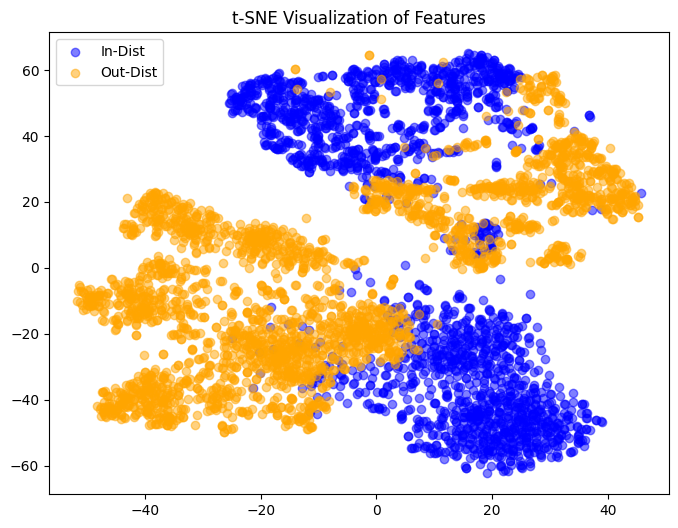

In [ ]:


# Impute missing values with the mean
imputer = SimpleImputer(strategy="mean")
scaled_combined_values = imputer.fit_transform(scaled_combined_values)

def plot_tsne(features, labels):
    """
    Visualize features using t-SNE.

    Parameters:
        features (array-like): Standardized feature values.
        labels (array-like): Labels (0: in-distribution, 1: out-distribution).
    """
    if features.shape[1] < 2 or features.shape[0] < 2:
        print("Insufficient features or samples for t-SNE visualization. Skipping...")
        return

    tsne = TSNE(n_components=2, random_state=42, init="random")
    reduced_features = tsne.fit_transform(features)
    plt.figure(figsize=(8, 6))
    for label, color, label_name in zip([0, 1], ["blue", "orange"], ["In-Dist", "Out-Dist"]):
        idx = labels == label
        plt.scatter(reduced_features[idx, 0], reduced_features[idx, 1], alpha=0.5, label=label_name, c=color)
    plt.title("t-SNE Visualization of Features")
    plt.legend()
    plt.show()

# Apply t-SNE visualization
plot_tsne(scaled_combined_values, labels)


Visualizing Features using Histogram of Global Norms...


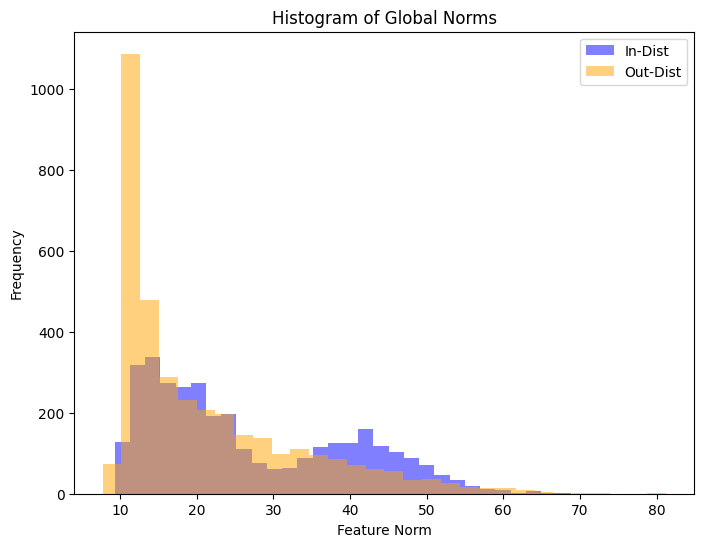

In [ ]:
# --------- Visualization Function --------- #

def plot_global_norm_histogram(features, labels):
    """
    Visualize the distribution of global feature norms for in-distribution
    and out-distribution datasets using histograms.

    Parameters:
        features (array-like): High-dimensional feature vectors (samples x features).
        labels (array-like): Labels corresponding to the features.
                             - 0: in-distribution
                             - 1: out-distribution

    Workflow:
        1. Compute the L2 norm (Euclidean norm) for each feature vector.
        2. Separate norms based on the labels (in-distribution vs. out-distribution).
        3. Plot histograms for each dataset with distinct colors for comparison.

    Notes:
        - The L2 norm is used to aggregate the high-dimensional features into a single scalar.
        - This helps in visualizing and comparing the overall magnitude of feature vectors
          across datasets.
        - Histograms provide an intuitive way to examine differences in feature distributions.

    Visualization:
        - Blue bars represent the in-distribution dataset.
        - Orange bars represent the out-distribution dataset.
        - Each bar shows the frequency of feature norms within a specific range.

    Example Use:
        plot_global_norm_histogram(scaled_combined_values, labels)
    """
    # Compute the L2 norm for each feature vector
    norms = np.linalg.norm(features, axis=1)

    # Initialize the plot
    plt.figure(figsize=(8, 6))

    # Plot histograms for in-distribution and out-distribution datasets
    plt.hist(norms[labels == 0], bins=30, alpha=0.5, label="In-Dist", color="blue")
    plt.hist(norms[labels == 1], bins=30, alpha=0.5, label="Out-Dist", color="orange")

    # Add title and labels
    plt.title("Histogram of Global Norms")
    plt.xlabel("Feature Norm")
    plt.ylabel("Frequency")

    # Add legend for clarity
    plt.legend()

    # Display the plot
    plt.show()

# --------- Visualization Calls --------- #

"""
Call the histogram visualization function to analyze the aggregated feature norms
for in-distribution and out-distribution datasets.
This helps in identifying whether the datasets have separable feature magnitudes.
"""

print("Visualizing Features using Histogram of Global Norms...")
plot_global_norm_histogram(scaled_combined_values, labels)


Visualizing Features using Boxplot...


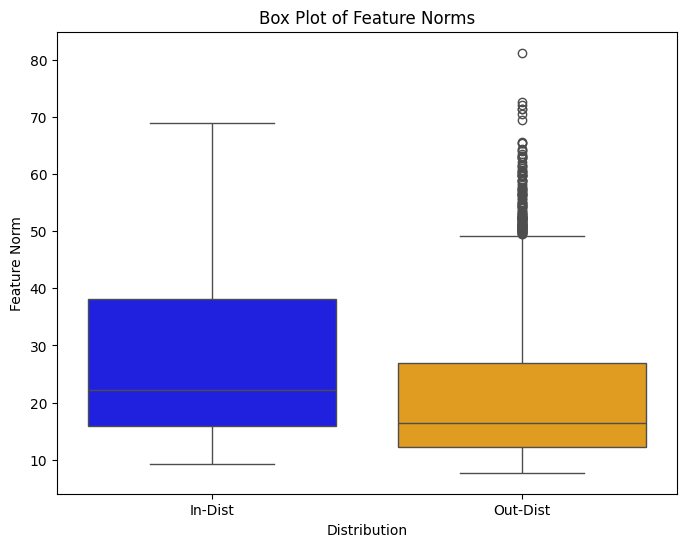

In [ ]:
# --------- Visualization Function --------- #

def plot_boxplot(features, labels):
    """
    Visualize the distribution of global feature norms using boxplots.

    Parameters:
        features (array-like): High-dimensional feature vectors (samples x features).
        labels (array-like): Labels corresponding to the features:
                             - 0: in-distribution
                             - 1: out-distribution

    Workflow:
        1. Compute the L2 norm (Euclidean norm) for each feature vector.
        2. Create a DataFrame to associate norms with their corresponding labels.
        3. Use a boxplot to compare the feature norm distributions across
           in-distribution and out-distribution datasets.

    Notes:
        - Boxplots provide insights into the spread and central tendency (median)
          of feature norms.
        - They help identify outliers and compare the overall distribution
          between datasets.

    Visualization:
        - The x-axis represents the dataset category (In-Dist or Out-Dist).
        - The y-axis represents the feature norm (L2).
        - The box represents the interquartile range (IQR) of the data.
        - The whiskers extend to show the range of the data within 1.5 * IQR from the quartiles.
        - Points outside the whiskers are outliers.

    Example Use:
        plot_boxplot(scaled_combined_values, labels)
    """
    # Compute the L2 norm for each feature vector
    norms = np.linalg.norm(features, axis=1)

    # Create a DataFrame for plotting
    data = pd.DataFrame({
        'Norm': norms,  # Feature norms
        'Distribution': ['In-Dist' if l == 0 else 'Out-Dist' for l in labels]  # Label as category
    })

    # Initialize the plot
    plt.figure(figsize=(8, 6))

    # Plot the boxplot using Seaborn
    sns.boxplot(x="Distribution", y="Norm", data=data, palette={"In-Dist": "blue", "Out-Dist": "orange"})

    # Add title and labels
    plt.title("Box Plot of Feature Norms")
    plt.xlabel("Distribution")
    plt.ylabel("Feature Norm")

    # Display the plot
    plt.show()

# --------- Visualization Calls --------- #

"""
Call the boxplot visualization function to analyze the spread and central tendency of
feature norms for in-distribution and out-distribution datasets. This provides an
intuitive summary of the dataset's feature distributions and helps identify any
outliers or anomalies.
"""

print("Visualizing Features using Boxplot...")
plot_boxplot(scaled_combined_values, labels)
